## Global Hotspots of Terrorism 1970 to 2017

In [0]:
SELECT * FROM terrorism_final LIMIT 10;

country,region,year,month,day,latitude,longitude,attacktype,targtype,gname,success,suicide,casualties,weapontype,propvalue
Dominican Republic,Central America & Caribbean,1970,7,2,18.456792,-69.951164,Assassination,Private Citizens & Property,MANO-D,1,0,1,Unknown,unknown
Mexico,North America,1970,0,0,19.371887,-99.086624,Hostage Taking (Kidnapping),Government (Diplomatic),23rd of September Communist League,1,0,0,Unknown,unknown
Philippines,Southeast Asia,1970,1,0,15.478598,120.599741,Assassination,Journalists & Media,Unknown,1,0,1,Unknown,unknown
Greece,Western Europe,1970,1,0,37.99749,23.762728,Bombing/Explosion,Government (Diplomatic),Unknown,1,0,0,Explosives,unknown
Japan,East Asia,1970,1,0,33.580412,130.396361,Facility/Infrastructure Attack,Government (Diplomatic),Unknown,1,0,0,Incendiary,unknown
United States,North America,1970,1,1,37.005105,-89.176269,Armed Assault,Police,Black Nationalists,1,0,0,Firearms,unknown
Uruguay,South America,1970,1,2,-34.891151,-56.187214,Assassination,Police,Tupamaros (Uruguay),0,0,0,Firearms,unknown
United States,North America,1970,1,2,37.791927,-122.225906,Bombing/Explosion,Utilities,Unknown,1,0,0,Explosives,22500
United States,North America,1970,1,2,43.076592,-89.412488,Facility/Infrastructure Attack,Military,New Year's Gang,1,0,0,Incendiary,60000
United States,North America,1970,1,3,43.07295,-89.386694,Facility/Infrastructure Attack,Government (General),New Year's Gang,1,0,0,Incendiary,unknown


In [0]:
SELECT 
    region,
    COUNT(*) as attacks
FROM terrorism_final
GROUP BY region
ORDER BY attacks DESC
LIMIT 10;

region,attacks
Middle East & North Africa,50474
South Asia,44974
South America,18978
Sub-Saharan Africa,17550
Western Europe,16639
Southeast Asia,12485
Central America & Caribbean,10344
Eastern Europe,5144
North America,3456
East Asia,802


We find that the highest number of terrorist attacks happened in the Middle east and north africa, while the south east asia region faced the least number of attacks, and seems to be relatively safer

In [0]:
SELECT 
    region, 
    COUNT(*) AS attacks
FROM terrorism_final
GROUP BY region;

region,attacks
Central America & Caribbean,10344
North America,3456
Southeast Asia,12485
Western Europe,16639
East Asia,802
South America,18978
Eastern Europe,5144
Sub-Saharan Africa,17550
Middle East & North Africa,50474
Australasia & Oceania,282


In [0]:
SELECT
    country,
    COUNT(*) AS attacks
FROM terrorism_final
GROUP BY country
ORDER BY attacks DESC
LIMit 10;

country,attacks
Iraq,24636
Pakistan,14368
Afghanistan,12731
India,11960
Colombia,8306
Philippines,6908
Peru,6096
El Salvador,5320
United Kingdom,5235
Turkey,4292


We find that Iraq faced the highest number of terrorist attacks and is the major contributer to the total attacks happening in the middle east. This can be attributed to terrorist organizations like ISIL which poperated from 2010 to 2014 in the region.

The Indian subcontinent and Afghanistan also can significantly high terrorist attacks

In [0]:
SELECT
    country,
    COUNT(*) AS attacks
FROM terrorism_final
GROUP BY country
ORDER BY attacks
LIMit 10;

country,attacks
Antigua and Barbuda,1
Wallis and Futuna,1
New Hebrides,1
St. Lucia,1
Vatican City,1
Falkland Islands,1
South Vietnam,1
Andorra,1
North Korea,1
International,1


In [0]:
SELECT 
    region, 
    SUM(COALESCE(casualties, 0)) AS total_killed
FROM terrorism_final
GROUP BY region
ORDER BY total_killed DESC
LIMIT 10;

region,total_killed
Middle East & North Africa,350570
South Asia,240925
Sub-Saharan Africa,130627
South America,45519
Southeast Asia,41708
Central America & Caribbean,37698
North America,26321
Western Europe,24942
Eastern Europe,19156
East Asia,10209


Not surprisingly, the middle East and north Africa has the highest number of casualties due to terrorism followed by south east asia and sahara

In [0]:
SELECT 
    country, 
    SUM(COALESCE(casualties, 0)) AS total_killed
FROM terrorism_final
GROUP BY country
ORDER BY total_killed DESC
LIMIT 10;

country,total_killed
Iraq,212204
Afghanistan,83526
Pakistan,64890
India,48135
Nigeria,32901
Sri Lanka,30699
Syria,29277
Colombia,24992
United States,24348
Philippines,22802


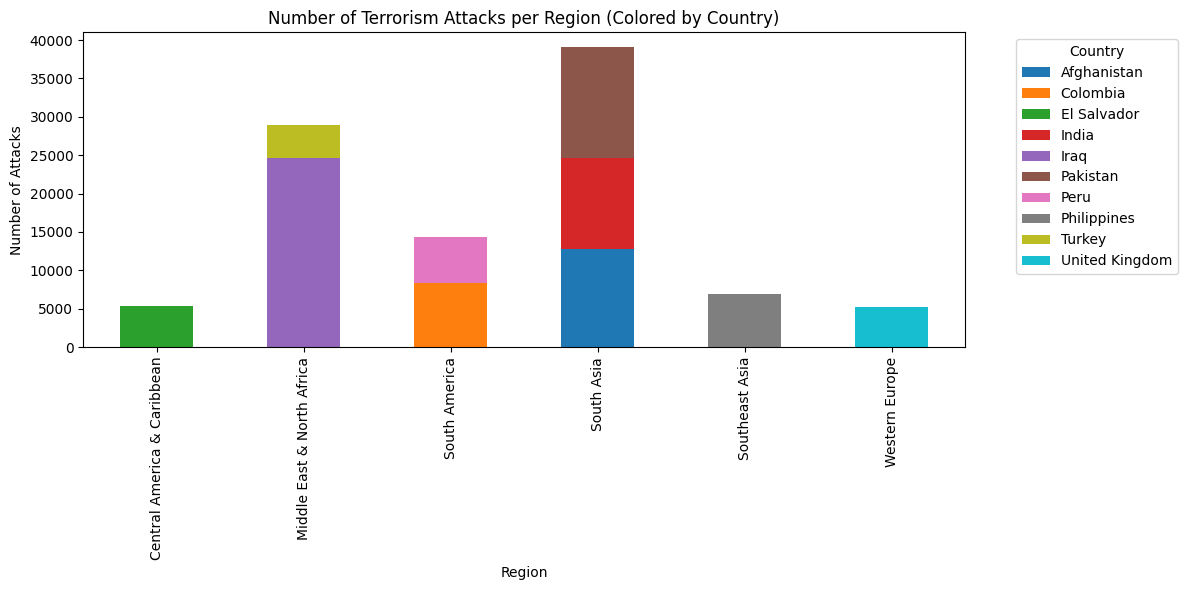

In [0]:
%python
import matplotlib.pyplot as plt

df = spark.sql("""
    SELECT region, country, COUNT(*) AS attacks
    FROM terrorism_final
    GROUP BY region, country
    ORDER BY attacks DESC
    LIMIT 10
""")

pdf = df.toPandas()

pivot_df = pdf.pivot_table(index='region', columns='country', values='attacks', fill_value=0)

pivot_df.plot(kind='bar', stacked=True, figsize=(12,6))
plt.xlabel('Region')
plt.ylabel('Number of Attacks')
plt.title('Number of Terrorism Attacks per Region (Colored by Country)')
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

We find that Pakistan faced the highest number of attacks in South Asia while India and Afghanistan had experienced around the same number of attacks. 

In the Middle East, almost all attacks were in Iraq and a little few in Turkey.

Both the Central America and Western Europe faced around the same number of attacks while South America faced a little higher of around 15,000 attacks in total. 

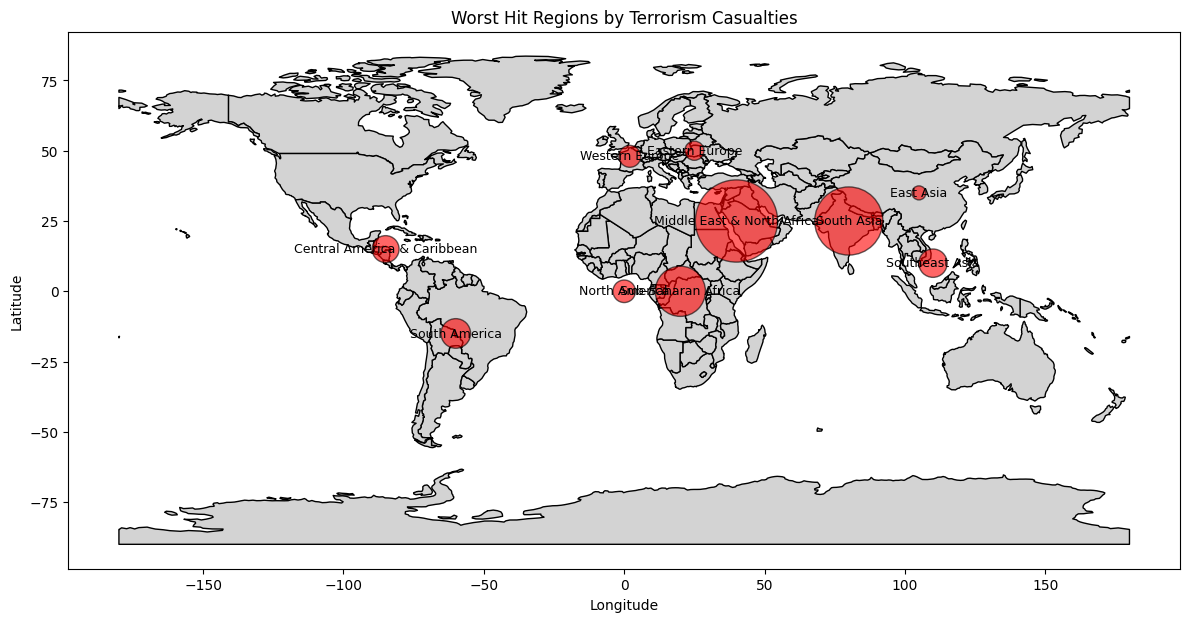

In [0]:
%python
import matplotlib.pyplot as plt
import geopandas as gpd

# Get top 10 deadliest regions by total casualties
df = spark.sql("""
    SELECT region, SUM(COALESCE(casualties, 0)) AS total_killed
    FROM terrorism_final
    GROUP BY region
    ORDER BY total_killed DESC
    LIMIT 10
""").toPandas()

# Approximate region centroids (latitude, longitude)
region_coords = {
    'Middle East & North Africa': (25, 40),
    'South Asia': (25, 80),
    'Sub-Saharan Africa': (0, 20),
    'Southeast Asia': (10, 110),
    'Eastern Europe': (50, 25),
    'Western Europe': (48, 2),
    'Central America & Caribbean': (15, -85),
    'East Asia': (35, 105),
    'South America': (-15, -60),
    'Central Asia': (45, 70)
}

df['lat'] = df['region'].map(lambda r: region_coords.get(r, (0,0))[0])
df['lon'] = df['region'].map(lambda r: region_coords.get(r, (0,0))[1])

world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

fig, ax = plt.subplots(figsize=(12,8))
world.plot(ax=ax, color='lightgray', edgecolor='black')

# Plot circles sized by total_killed
ax.scatter(df['lon'], df['lat'], s=df['total_killed']/100, color='red', alpha=0.6, edgecolors='black')

for _, row in df.iterrows():
    ax.text(row['lon'], row['lat'], row['region'], fontsize=9, ha='center', va='center')

plt.title('Worst Hit Regions by Terrorism Casualties')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

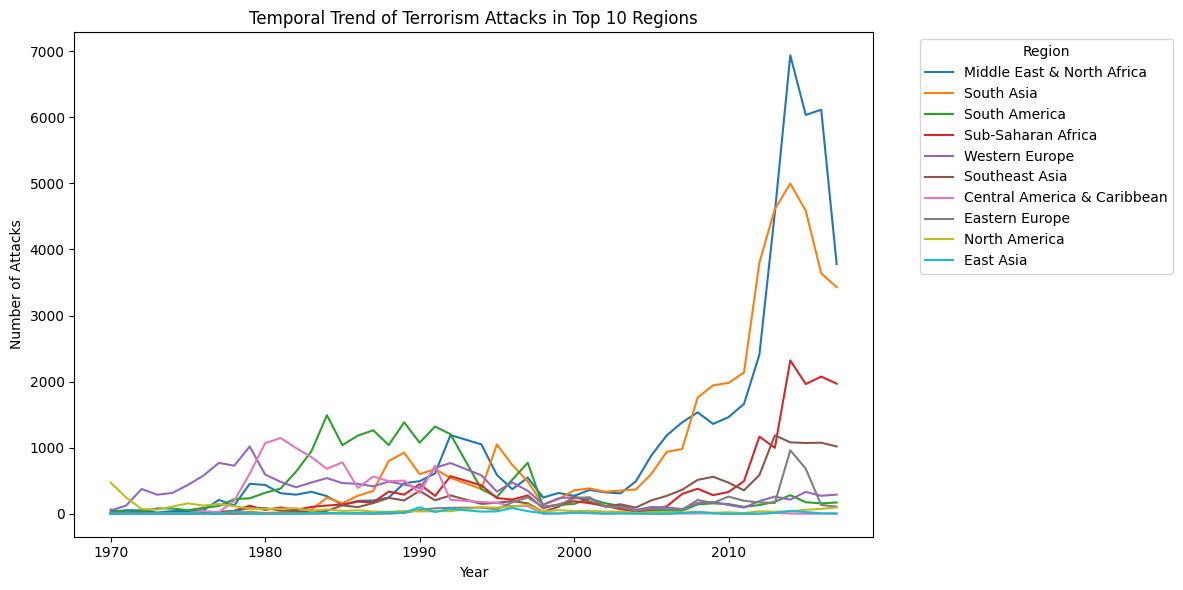

In [0]:
%python
import matplotlib.pyplot as plt

# Get top 10 regions by total attacks
top_regions = spark.sql("""
    SELECT region
    FROM terrorism_final
    GROUP BY region
    ORDER BY COUNT(*) DESC
    LIMIT 10
""").toPandas()['region'].tolist()

# Get yearly attack counts for top regions
df = spark.sql(f"""
    SELECT region, year, COUNT(*) AS attacks
    FROM terrorism_final
    WHERE region IN ({','.join(["'" + r + "'" for r in top_regions])})
    GROUP BY region, year
    ORDER BY region, year
""").toPandas()

plt.figure(figsize=(12,6))
for region in top_regions:
    region_data = df[df['region'] == region]
    plt.plot(region_data['year'], region_data['attacks'], label=region)

plt.xlabel('Year')
plt.ylabel('Number of Attacks')
plt.title('Temporal Trend of Terrorism Attacks in Top 10 Regions')
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


We find that the number of attacks have significantly risen in all regions after 2010. However, East Asia is an exception to this trend, where the number of attacks have been constant (nearly close to 0) showing that it largely remained unaffected by the global geopolitical events of the time.

### Analysis - Middle East and North Africa

In [0]:
SELECT
    country,
    COUNT(*) AS attacks,
    SUM(COALESCE(casualties, 0)) AS total_killed
FROM terrorism_final
WHERE region = 'Middle East & North Africa'
GROUP BY country
ORDER BY attacks DESC
LIMIT 10;

country,attacks,total_killed
Iraq,24636,212204
Turkey,4292,16697
Yemen,3347,18104
Algeria,2743,20196
Egypt,2479,8679
Lebanon,2478,14964
Libya,2249,5901
West Bank and Gaza Strip,2227,4493
Syria,2201,29277
Israel,2183,9570


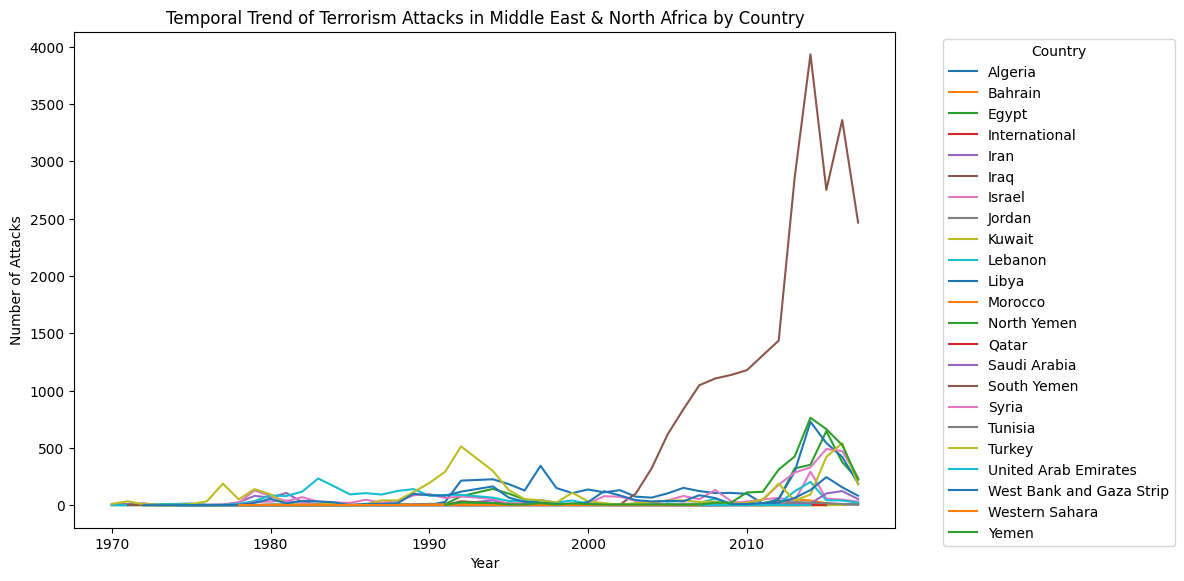

In [0]:
%python
import matplotlib.pyplot as plt

# Get yearly attack counts for each country in Middle East & North Africa
df = spark.sql("""
    SELECT country, year, COUNT(*) AS attacks
    FROM terrorism_final
    WHERE region = 'Middle East & North Africa'
    GROUP BY country, year
    ORDER BY country, year
""").toPandas()

plt.figure(figsize=(12,6))
for country in df['country'].unique():
    country_data = df[df['country'] == country]
    plt.plot(country_data['year'], country_data['attacks'], label=country)

plt.xlabel('Year')
plt.ylabel('Number of Attacks')
plt.title('Temporal Trend of Terrorism Attacks in Middle East & North Africa by Country')
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

The above graphs confirms the Middle East and North Africa as a highly volatile region with a lot of terrorist incidents. However, the number of incidents grew heavily due to Iraq after 2000. and then saw a sharp increase of attacks in Iraq after 2010.

The initial rise in attacks after 2000 can be attributed to the Iraq war and the fall of the Saddam Hussain regime at the hands of the United States. Iraq, which had not seen any terrorist attacks before this period, has seen a sharp rise in attacks reaching above 1100 incidents per year.

The most dramtic rise came in 2014, when the number of incidents rose to over 4000 at its peak. This can be attributed to the rise of ISIL during this period.

Despite the regional instability, many north African nations like Bahrain, Qatar, Jordan etc seems to have faced very little or no spilloff of terrorist activity in their nations.

In [0]:
SELECT
    country,
    COUNT(*) AS attacks,
    SUM(COALESCE(casualties, 0)) AS total_killed,
    ROUND((total_killed / attacks), 2) as avg_killed
FROM terrorism_final
WHERE region = 'Middle East & North Africa'
GROUP BY country
ORDER BY attacks DESC
LIMIT 10;

country,attacks,total_killed,avg_killed
Iraq,24636,212204,8.61
Turkey,4292,16697,3.89
Yemen,3347,18104,5.41
Algeria,2743,20196,7.36
Egypt,2479,8679,3.5
Lebanon,2478,14964,6.04
Libya,2249,5901,2.62
West Bank and Gaza Strip,2227,4493,2.02
Syria,2201,29277,13.3
Israel,2183,9570,4.38


The above data reveals that the attacks in Iraq were not only greater but they are even deadlier than other attacks since Iraq has the highest overall casualty ratio.

### South Asia

In [0]:
SELECT
    country,
    COUNT(*) AS attacks
FROM terrorism_final
WHERE region = "South Asia"
GROUP BY country
ORDER BY attacks DESC
LIMIT 10;

country,attacks
Pakistan,14368
Afghanistan,12731
India,11960
Sri Lanka,3022
Bangladesh,1648
Nepal,1215
Maldives,22
Bhutan,6
Mauritius,2


In [0]:
SELECT
    country,
    COUNT(*) AS attacks, 
    SUM(COALESCE(casualties, 0)) AS total_killed,
    ROUND((total_killed / attacks), 2) as avg_killed
FROM terrorism_final
WHERE region = 'South Asia'
GROUP BY country
ORDER BY attacks DESC
LIMIT 10;

country,attacks,total_killed,avg_killed
Pakistan,14368,64890,4.52
Afghanistan,12731,83526,6.56
India,11960,48135,4.02
Sri Lanka,3022,30699,10.16
Bangladesh,1648,9427,5.72
Nepal,1215,4091,3.37
Maldives,22,142,6.45
Bhutan,6,14,2.33
Mauritius,2,1,0.5


We can observe that Pakistan and Afghanistan faced the highest number of attacks total. However, Srilanka and Pakistan and Maldieves faced the most deadliest attacks with the highest casualty ratio. 

Srilanka faced the deadliest attacks in all of South Asia, with aound 10 people dying per attack. 

The country Mauritius faced the least deadliest sttacks, with only 1 person killed out of the total 2 attacks. 

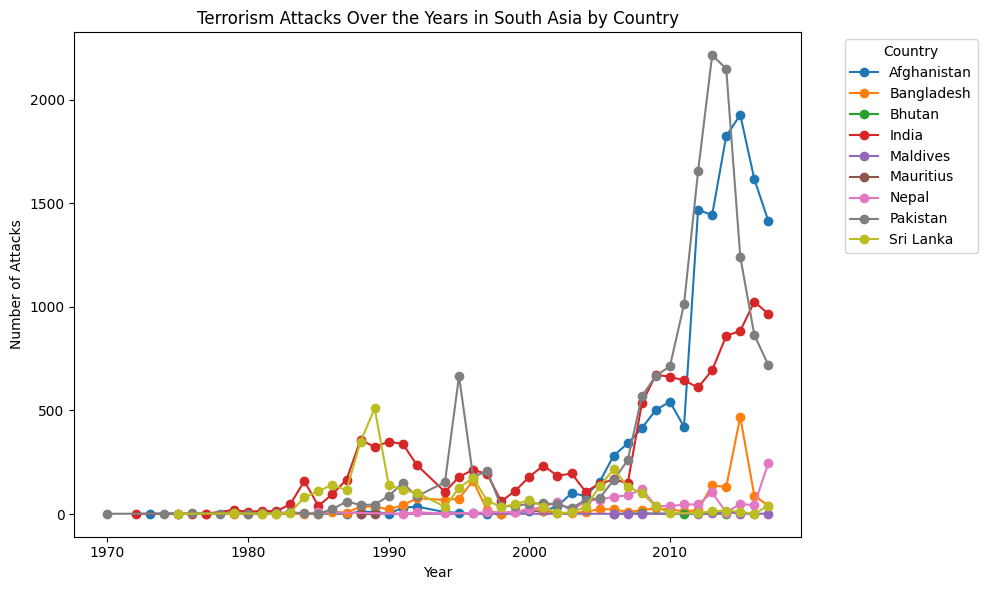

In [0]:
%python
import matplotlib.pyplot as plt

df = spark.sql("""
    SELECT country, year, COUNT(*) AS attacks
    FROM terrorism_final
    WHERE region = 'South Asia'
    GROUP BY country, year
    ORDER BY country, year
""").toPandas()

plt.figure(figsize=(10,6))
for country in df['country'].unique():
    country_data = df[df['country'] == country]
    plt.plot(country_data['year'], country_data['attacks'], marker='o', label=country)
plt.xlabel('Year')
plt.ylabel('Number of Attacks')
plt.title('Terrorism Attacks Over the Years in South Asia by Country')
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

The number of terrorist attacks in South Asia increased withpost 2005. They increased significantly after 2010 following the same trend as of the Middle East

### South America

In [0]:
SELECT
    country,
    COUNT(*) AS attacks
FROM terrorism_final
WHERE region = 'South America'
GROUP BY country
ORDER BY attacks DESC
LIMIT 10;

country,attacks
Colombia,8306
Peru,6096
Chile,2365
Argentina,815
Bolivia,314
Venezuela,293
Brazil,273
Ecuador,220
Paraguay,114
Uruguay,82


Databricks visualization. Run in Databricks to view.

In [0]:
SELECT
    country,
    COUNT(*) AS attacks,
    CASE 
        WHEN year BETWEEN 1970 AND 1980 THEN '1970-1980'
        WHEN year BETWEEN 1980 AND 1990 THEN '1980-1990'
        WHEN year BETWEEN 1990 AND 2000 THEN '1990-2000'
        WHEN year BETWEEN 2000 AND 2010 THEN '2000-2010'
        WHEN year BETWEEN 2010 AND 2014 THEN '2010-2014'
        ELSE 'Other'
    END AS year_group
FROM terrorism_final
WHERE region = 'South America'
GROUP BY country, year_group
ORDER BY attacks DESC;

country,attacks,year_group
Peru,4654,1980-1990
Colombia,3159,1980-1990
Colombia,2621,1990-2000
Chile,1864,1980-1990
Peru,1289,1990-2000
Colombia,1015,2000-2010
Colombia,589,2010-2014
Colombia,560,1970-1980
Colombia,362,Other
Argentina,335,1970-1980


Databricks visualization. Run in Databricks to view.

In [0]:
SELECT
    country,
    COUNT(*) AS attacks,
    SUM(COALESCE(casualties, 0)) AS total_killed,
    ROUND((total_killed / attacks), 2) as avg_killed
FROM terrorism_final
WHERE region = 'South America'
GROUP BY country
ORDER BY attacks DESC
LIMIT 10;

country,attacks,total_killed,avg_killed
Colombia,8306,24992,3.01
Peru,6096,16849,2.76
Chile,2365,983,0.42
Argentina,815,1245,1.53
Bolivia,314,208,0.66
Venezuela,293,474,1.62
Brazil,273,363,1.33
Ecuador,220,133,0.6
Paraguay,114,128,1.12
Uruguay,82,12,0.15


We find a very interesting pattern in South America. The number of terrorist incidents were very high in the region from 1970 to 2010. However, after 2010, the number of attacks have significantly reduced.

This is an exception from other regions like South Asia and Middle East where the number of attacks actually increased significantly post 2014.

While the major drivers of incidents in the middle east were the rise of ISIL and Taliban which grew significantly post 2014, the major drivers in South America were maoists and Narco-terrorists which significantly weakened during this period. By 2017, there were literally no attacks in most of the South American nations showing enormous success in their counter-terrorism strategy.

### Sub-Saharan Africa

In [0]:
SELECT 
    country, 
    COUNT(*) AS attacks
FROM terrorism_final
WHERE region = 'Sub-Saharan Africa'
GROUP BY country
ORDER BY attacks DESC
LIMIT 10;

country,attacks
Somalia,4142
Nigeria,3907
South Africa,2016
Sudan,967
Democratic Republic of the Congo,775
Kenya,683
Burundi,613
Mali,566
Angola,499
Uganda,394


Databricks visualization. Run in Databricks to view.

In [0]:
SELECT
    country,
    COUNT(*) AS attacks,
    CASE 
        WHEN year BETWEEN 1970 AND 1980 THEN '1970-1980'
        WHEN year BETWEEN 1980 AND 1990 THEN '1980-1990'
        WHEN year BETWEEN 1990 AND 2000 THEN '1990-2000'
        WHEN year BETWEEN 2000 AND 2010 THEN '2000-2010'
        WHEN year BETWEEN 2010 AND 2014 THEN '2010-2014'
        ELSE 'Other'
    END AS year_group
FROM terrorism_final
WHERE region = 'Sub-Saharan Africa'
GROUP BY country, year_group
ORDER BY attacks DESC;


country,attacks,year_group
Nigeria,1851,2010-2014
Somalia,1724,2010-2014
Nigeria,1655,Other
Somalia,1634,Other
South Africa,1130,1980-1990
South Africa,712,1990-2000
Somalia,606,2000-2010
Democratic Republic of the Congo,455,Other
Sudan,437,Other
Mali,361,Other


Databricks visualization. Run in Databricks to view.

The major victims of the terrorist attacks in Africa are Uganda and Nigeria, whose number of attacks increased significantly post 2010. 

South Africa however, is an exception where, the number of attacks touched arounf 1,130 in the 1980s but by 2000, they almost reduced to zero.

### Western Europe

In [0]:
SELECT 
    CASE 
        WHEN country IN ('Germany', 'West Germany (FRG)', 'East Germany (GDR)') THEN 'Germany'
        ELSE country
    END AS country, 
    COUNT(*) AS attacks
FROM terrorism_final 
WHERE region = 'Western Europe' 
GROUP BY 
    CASE 
        WHEN country IN ('Germany', 'West Germany (FRG)', 'East Germany (GDR)') THEN 'Germany'
        ELSE country
    END
ORDER BY attacks DESC
LIMIT 10;

country,attacks
United Kingdom,5235
Spain,3249
France,2693
Italy,1565
Germany,1276
Greece,1275
Ireland,307
Belgium,154
Portugal,140
Sweden,132


Databricks visualization. Run in Databricks to view.

In [0]:
SELECT
    country,
    COUNT(*) AS attacks,
    CASE 
        WHEN year BETWEEN 1970 AND 1980 THEN '1970-1980'
        WHEN year BETWEEN 1980 AND 1990 THEN '1980-1990'
        WHEN year BETWEEN 1990 AND 2000 THEN '1990-2000'
        WHEN year BETWEEN 2000 AND 2010 THEN '2000-2010'
        WHEN year BETWEEN 2010 AND 2014 THEN '2010-2014'
        ELSE 'Other'
    END AS year_group
FROM terrorism_final
WHERE region = 'Western Europe'
GROUP BY country, year_group
ORDER BY attacks DESC;

country,attacks,year_group
United Kingdom,1778,1970-1980
United Kingdom,1329,1980-1990
Spain,1267,1980-1990
Italy,1131,1970-1980
United Kingdom,1128,1990-2000
Spain,1088,1970-1980
France,917,1990-2000
France,791,1980-1990
Spain,585,1990-2000
France,569,1970-1980


Databricks visualization. Run in Databricks to view.

In [0]:
SELECT
    country,
    COUNT(*) AS attacks,
    SUM(COALESCE(casualties, 0)) AS total_killed,
    ROUND((total_killed / attacks), 2) as avg_killed
FROM terrorism_final
WHERE region = 'Western Europe'
GROUP BY country
ORDER BY attacks DESC
LIMIT 10;

country,attacks,total_killed,avg_killed
United Kingdom,5235,9474,1.81
Spain,3249,6217,1.91
France,2693,3048,1.13
Italy,1565,1709,1.09
Greece,1275,1058,0.83
Germany,735,764,1.04
West Germany (FRG),541,959,1.77
Ireland,307,148,0.48
Belgium,154,593,3.85
Portugal,140,127,0.91
